# Biểu đồ 5 chỉ số — phiên bản tối ưu cho slide

Phiên bản này dùng palette dịu hơn, làm nổi bật **Đề xuất**, giảm grid/tick/nhãn lặp, bỏ chữ `0` trên baseline và mở rộng hai panel hàng dưới để tận dụng không gian.

- Hàng 1: **Df-AUC ↓, Df-F1 ↓, MIA ↓**
- Hàng 2: **Dt-AUC ↑, Dt-F1 ↑**
- Dùng chung thang Y `0–1` và một legend.
- Mặc định **không có tiêu đề hình** vì slide đã có tiêu đề. Có thể bật `SHOW_FIGURE_TITLE = True`.


In [26]:
# =============================================================================
# CELL 1 — Cấu hình hiển thị (tối ưu cho slide 16:9)
# =============================================================================
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --- knobs -------------------------------------------------------------------
SHARED_YLIM       = (0.0, 1.0)
SHOW_VALUES_MIMIC = False      # 18 cột/panel: không nên hiện số trên từng cột
SHOW_VALUES_IU    = True       # IU ít cột hơn, có thể bật
SHOW_FIGURE_TITLE = False      # Slide đã có tiêu đề -> tắt để hình thoáng hơn
SHOW_ROW_LABELS   = False    # da bo hai dong nhan nhom o le trai
OUTDIR            = "figures"
DPI               = 300
DATA_CSV          = os.path.join("experiments", "chart_data.csv")

# --- thứ tự phương pháp -------------------------------------------------------
METHODS = [
    "OG",
    "GOLD",
    "NegGrad+",
    "CF-k",
    "Forget-MI",
    "Ours",
]
METHOD_LABELS = {
    "OG":        "θ$_{og}$",
    "GOLD":      "θ$_{re}$ (gold)",
    "NegGrad+":  "NegGrad+",
    "CF-k":      "CF-k",
    "Forget-MI": "Forget-MI",
    "Ours":      "Đề xuất",
}

# IU chỉ chạy 4 mô hình (báo cáo không có NegGrad+ và CF-k trên IU)
METHODS_IU = ["OG", "GOLD", "Forget-MI", "Ours"]

FORGET_PCTS = ["3%", "6%", "10%"]

ROW_FORGET = [("Df_AUC", "Df, AUC ↓"), ("Df_F1", "Df, F1 ↓"), ("MIA", "MIA ↓")]
ROW_RETAIN = [("Dt_AUC", "Dt, AUC ↑"), ("Dt_F1", "Dt, F1 ↑")]
METRIC_COLS = [m for m, _ in ROW_FORGET + ROW_RETAIN]

# --- palette: màu cơ bản, rõ ràng, hợp PowerPoint ---------------------------
# Dùng các màu Office quen thuộc để 6 phương pháp dễ phân biệt trên slide.
COLORS = {
    "OG":        "#4472C4",  # xanh dương
    "GOLD":      "#ED7D31",  # cam
    "NegGrad+":  "#70AD47",  # xanh lá
    "CF-k":      "#C00000",  # đỏ
    "Forget-MI": "#7030A0",  # tím
    "Ours":      "#00B0F0",  # xanh cyan
}

# Hình "hiệu quả tài nguyên" chỉ so 2 đối tượng -> dùng riêng cặp đỏ / xanh lá.
COST_COLORS = {
    "Forget-MI": "#C00000",   # đỏ  — tinh chỉnh toàn bộ tham số
    "Ours":      "#00B050",   # xanh lá — phương pháp đề xuất
    "Fisher":    "#A9D08E",   # xanh lá nhạt — phần ước lượng Fisher
}

C = {
    "surface":   "#FFFFFF",
    "primary":   "#17202A",
    "secondary": "#66717C",
    "muted":     "#7A858F",
    "grid":      "#E8ECEF",
    "missing":   "#A9B0B6",
}

mpl.rcParams.update({
    "figure.facecolor": C["surface"],
    "axes.facecolor": C["surface"],
    "savefig.facecolor": C["surface"],
    "text.color": C["primary"],
    "axes.labelcolor": C["secondary"],
    "xtick.color": C["secondary"],
    "ytick.color": C["secondary"],
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
})

os.makedirs(OUTDIR, exist_ok=True)
print("Palette slide-ready | số phương pháp:", len(METHODS))


Palette slide-ready | số phương pháp: 6


## Cell 2 — Dữ liệu

Định dạng **long**: mỗi dòng = 1 bộ (dataset, forget_pct, method). Cột:

`dataset, forget_pct, method, Df_AUC, Df_F1, Dt_AUC, Dt_F1, MIA, unlearn_time_hours, gpu_peak_GB`

Ô nào chưa có số thì để trống — notebook bỏ qua cột bar đó (vẽ dấu `–`) và in danh sách còn thiếu.

In [27]:
# =============================================================================
# CELL 2 — Nạp dữ liệu (tự tạo template nếu chưa có)
# =============================================================================
RES_COLS = ["t_fisher_s", "t_train_s", "trainable_params"]
EXTRA_COLS = ["CE_f"]
ALL_COLS = ["dataset", "forget_pct", "method"] + METRIC_COLS + EXTRA_COLS + RES_COLS

# -----------------------------------------------------------------------------
# Số liệu chốt: KLTN_NHNHU_clone_3/Chapter4/chapter4.tex
#   Bảng tab:mimic3 / tab:mimic6 / tab:mimic10 / tab:main-iu  (đo sau 30 epoch)
#   Chi phí: Mục "Chi phí tài nguyên" (fig:cost) — T_core = Fisher + Train
# -----------------------------------------------------------------------------
def _row(df_auc, df_f1, dt_auc, dt_f1, mia, ce):
    return dict(Df_AUC=df_auc, Df_F1=df_f1, Dt_AUC=dt_auc, Dt_F1=dt_f1, MIA=mia, CE_f=ce)

SEED = {
    # ---- MIMIC-CXR 3% (Bảng 4.3) --------------------------------------------
    ("MIMIC", "3%", "OG"):        _row(0.731, 0.419, 0.695, 0.384, 0.657, 1.97),
    ("MIMIC", "3%", "GOLD"):      _row(0.498, 0.179, 0.615, 0.297, 0.423, 4.74),
    ("MIMIC", "3%", "NegGrad+"):  _row(0.162, 0.000, 0.615, 0.316, 0.000, 129.45),
    ("MIMIC", "3%", "CF-k"):      _row(0.912, 0.701, 0.669, 0.380, 0.637, 1.49),
    ("MIMIC", "3%", "Forget-MI"): _row(0.623, 0.278, 0.648, 0.307, 0.627, 3.58),
    ("MIMIC", "3%", "Ours"):      _row(0.683, 0.365, 0.704, 0.394, 0.552, 2.07),
    # ---- MIMIC-CXR 6% (Bảng 4.4) --------------------------------------------
    ("MIMIC", "6%", "OG"):        _row(0.730, 0.434, 0.695, 0.384, 0.736, 1.76),
    ("MIMIC", "6%", "GOLD"):      _row(0.596, 0.339, 0.665, 0.381, 0.613, 2.45),
    ("MIMIC", "6%", "NegGrad+"):  _row(0.102, 0.000, 0.592, 0.318, 0.000, 114.59),
    ("MIMIC", "6%", "CF-k"):      _row(0.927, 0.771, 0.676, 0.403, 0.663, 1.13),
    ("MIMIC", "6%", "Forget-MI"): _row(0.633, 0.296, 0.641, 0.296, 0.773, 3.14),
    ("MIMIC", "6%", "Ours"):      _row(0.670, 0.353, 0.689, 0.370, 0.706, 2.09),
    # ---- MIMIC-CXR 10% (Bảng 4.5) -------------------------------------------
    ("MIMIC", "10%", "OG"):        _row(0.757, 0.469, 0.695, 0.384, 0.717, 1.66),
    ("MIMIC", "10%", "GOLD"):      _row(0.547, 0.274, 0.607, 0.338, 0.364, 3.26),
    ("MIMIC", "10%", "NegGrad+"):  _row(0.207, 0.000, 0.570, 0.278, 0.000, 99.53),
    ("MIMIC", "10%", "CF-k"):      _row(0.925, 0.775, 0.667, 0.383, 0.706, 1.18),
    ("MIMIC", "10%", "Forget-MI"): _row(0.704, 0.349, 0.653, 0.308, 0.616, 2.55),
    ("MIMIC", "10%", "Ours"):      _row(0.728, 0.417, 0.692, 0.384, 0.731, 1.68),
    # ---- IU 3% (Bảng 4.7) — báo cáo KHÔNG chạy NegGrad+/CF-k trên IU --------
    ("IU", "3%", "OG"):        _row(1.000, 1.000, 0.676, 0.622, 0.990, 0.00),
    ("IU", "3%", "GOLD"):      _row(0.651, 0.587, 0.670, 0.614, 0.545, 2.33),
    ("IU", "3%", "Forget-MI"): _row(0.854, 0.616, 0.635, 0.533, 0.581, 3.02),
    ("IU", "3%", "Ours"):      _row(0.710, 0.334, 0.590, 0.351, 0.560, 37.77),
}

# Chi phí (fig:cost). Forget-MI: 1 khối train, không có bước Fisher.
COST = {
    ("MIMIC", "3%",  "Forget-MI"): dict(t_fisher_s=0.0,   t_train_s=2172.5, trainable_params=113238164),
    ("MIMIC", "6%",  "Forget-MI"): dict(t_fisher_s=0.0,   t_train_s=3995.5, trainable_params=113238164),
    ("MIMIC", "10%", "Forget-MI"): dict(t_fisher_s=0.0,   t_train_s=6403.3, trainable_params=113238164),
    ("IU",    "3%",  "Forget-MI"): dict(t_fisher_s=0.0,   t_train_s=1882.6, trainable_params=113238164),
    ("MIMIC", "3%",  "Ours"):      dict(t_fisher_s=270.9, t_train_s=1592.7, trainable_params=1451008),
    ("MIMIC", "6%",  "Ours"):      dict(t_fisher_s=286.9, t_train_s=3102.4, trainable_params=1451008),
    ("MIMIC", "10%", "Ours"):      dict(t_fisher_s=294.2, t_train_s=5447.5, trainable_params=1451008),
    ("IU",    "3%",  "Ours"):      dict(t_fisher_s=259.3, t_train_s=1273.5, trainable_params=1451008),
}

def make_template(path):
    rows = []
    grid = [("MIMIC", p) for p in FORGET_PCTS] + [("IU", "3%")]
    for ds, pct in grid:
        for m in METHODS:
            r = {"dataset": ds, "forget_pct": pct, "method": m}
            r.update({c: np.nan for c in METRIC_COLS + EXTRA_COLS + RES_COLS})
            r.update(SEED.get((ds, pct, m), {}))
            r.update(COST.get((ds, pct, m), {}))
            rows.append(r)
    df = pd.DataFrame(rows)[ALL_COLS]
    os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
    df.to_csv(path, index=False)
    return df

if os.path.exists(DATA_CSV):
    data = pd.read_csv(DATA_CSV)
    print("Da nap:", DATA_CSV)
else:
    data = make_template(DATA_CSV)
    print("Chua co du lieu -> da tao template:", DATA_CSV)
    print("   => Mo file, dien so, roi chay lai cell nay.")

for c in ALL_COLS:
    if c not in data.columns:
        data[c] = np.nan
for c in METRIC_COLS + EXTRA_COLS + RES_COLS:
    data[c] = pd.to_numeric(data[c], errors="coerce")

# T_core = Fisher + Train (Forget-MI khong co buoc Fisher -> coi nhu 0)
data["t_core_s"] = data["t_fisher_s"].fillna(0.0) + data["t_train_s"]

missing = []
for r in data.itertuples():
    gaps = [c for c in METRIC_COLS if pd.isna(getattr(r, c))]
    if gaps:
        missing.append("{} {} {}: {}".format(r.dataset, r.forget_pct, r.method, ", ".join(gaps)))
if missing:
    print("\nCon thieu {} dong (o trong se khong ve cot bar):".format(len(missing)))
    for s in missing[:24]:
        print("  -", s)

# Table view — đi kèm hình (một vài màu < 3:1 tương phản nền nên cần bảng số).
display(data.set_index(["dataset", "forget_pct", "method"])[METRIC_COLS + EXTRA_COLS].round(3))

Da nap: experiments\chart_data.csv

Con thieu 2 dong (o trong se khong ve cot bar):
  - IU 3% NegGrad+: Df_AUC, Df_F1, MIA, Dt_AUC, Dt_F1
  - IU 3% CF-k: Df_AUC, Df_F1, MIA, Dt_AUC, Dt_F1


Df_AUC  Df_F1    MIA  Dt_AUC  Dt_F1    CE_f
dataset forget_pct method                                                
MIMIC   3%         OG          0.731  0.419  0.657   0.695  0.384    1.97
                   GOLD        0.498  0.179  0.423   0.615  0.297    4.74
                   NegGrad+    0.162  0.000  0.000   0.615  0.316  129.45
                   CF-k        0.912  0.701  0.637   0.669  0.380    1.49
                   Forget-MI   0.623  0.278  0.627   0.648  0.307    3.58
                   Ours        0.683  0.365  0.552   0.704  0.394    2.07
        6%         OG          0.730  0.434  0.736   0.695  0.384    1.76
                   GOLD        0.596  0.339  0.613   0.665  0.381    2.45
                   NegGrad+    0.102  0.000  0.000   0.592  0.318  114.59
                   CF-k        0.927  0.771  0.663   0.676  0.403    1.13
                   Forget-MI   0.633  0.296  0.773   0.641  0.296    3.14
                   Ours        0.670  0.353  0.706   0.689  0.370    2.09
        10%        OG          0.757  0.469  0.717   0.695  0.384    1.66
                   GOLD        0.547  0.274  0.364   0.607  0.338    3.26
                   NegGrad+    0.207  0.000  0.000   0.570  0.278   99.53
                   CF-k        0.925  0.775  0.706   0.667  0.383    1.18
                   Forget-MI   0.704  0.349  0.616   0.653  0.308    2.55
                   Ours        0.728  0.417  0.731   0.692  0.384    1.68
IU      3%         OG          1.000  1.000  0.990   0.676  0.622    0.00
                   GOLD        0.651  0.587  0.545   0.670  0.614    2.33
                   NegGrad+      NaN    NaN    NaN     NaN    NaN     NaN
                   CF-k          NaN    NaN    NaN     NaN    NaN     NaN
                   Forget-MI   0.854  0.616  0.581   0.635  0.533    3.02
                   Ours        0.710  0.334  0.560   0.590  0.351   37.77

In [28]:
# =============================================================================
# CELL 3 — Hàm vẽ: lưới 6 panel (3 + 3), dùng chung 1 legend
# =============================================================================
GROUP_WIDTH = 0.72     # tổng bề rộng của các cột trong 1 nhóm
BAR_FILL    = 0.84     # cột hẹp hơn slot -> có khoảng trắng nhỏ

# Panel thứ 6: thời gian lõi. Thang riêng (giây), KHÔNG dùng chung 0–1.
PANEL_COST = ("t_core_s", "T$_{core}$ (giây) ↓")

def _get(df, ds, pct, method, col):
    s = df[(df.dataset == ds) & (df.forget_pct == pct) & (df.method == method)][col]
    return float(s.iloc[0]) if len(s) and pd.notna(s.iloc[0]) else np.nan

# Thang Y chung cho 5 chỉ số, chia 0.1 một vạch
YTICKS = np.round(np.arange(0.0, 1.001, 0.1), 2)


def _cost_axis(df, ds, groups, methods):
    """Trần trục Y và các vạch chia cho panel thời gian lõi."""
    vals = [_get(df, ds, g, m, PANEL_COST[0]) for g in groups for m in methods]
    vals = [v for v in vals if not np.isnan(v)]
    if not vals:
        return (0.0, 1.0), np.array([0.0, 1.0])
    step = 2000.0 if max(vals) > 4000 else 1000.0
    top = np.ceil(max(vals) / step) * step + step * 0.35
    return (0.0, top), np.arange(0.0, top, step)


def _panel(ax, df, ds, groups, col, title, show_values=False, show_y=False,
           methods=None, ylim=None, yticks=None, fmt=None):
    """Một panel: X = tỷ lệ quên; màu = phương pháp."""
    methods = METHODS if methods is None else methods
    ylim   = SHARED_YLIM if ylim is None else ylim
    yticks = YTICKS if yticks is None else yticks
    fmt    = (lambda v: ("%.2f" % v).lstrip("0")) if fmt is None else fmt

    lo, hi = ylim
    span = hi - lo
    n = len(methods)
    centers = np.arange(len(groups))
    slot = GROUP_WIDTH / n
    width = slot * BAR_FILL

    for mi, method in enumerate(methods):
        xs = centers - GROUP_WIDTH / 2 + (mi + 0.5) * slot
        vals = np.array([_get(df, ds, g, method, col) for g in groups], dtype=float)

        # NaN được vẽ bằng dấu –, giá trị 0 bằng một gạch nhỏ ở baseline.
        heights = np.where(np.isnan(vals), 0.0, vals)
        ax.bar(xs, heights, width=width, color=COLORS[method],
               edgecolor="none", linewidth=0, zorder=3)

        for x, v in zip(xs, vals):
            if np.isnan(v):
                ax.text(x, lo + 0.015 * span, "–", ha="center", va="bottom",
                        fontsize=7, color=C["missing"], zorder=4)
            elif v == 0:
                ax.plot([x - width*0.22, x + width*0.22],
                        [lo + 0.012 * span] * 2,
                        lw=2, color=COLORS[method], solid_capstyle="round", zorder=4)
            elif show_values:
                # Nhãn nằm ngang ngay trên đầu cột; cột chạm trần thì ghi bên trong.
                inside = v > lo + 0.94 * span
                ax.text(x, v - 0.015 * span if inside else v + 0.012 * span,
                        fmt(v),
                        ha="center", va="top" if inside else "bottom",
                        fontsize=8.2,
                        color=C["surface"] if inside else C["secondary"], zorder=4)

    # Tiêu đề metric
    ax.set_title(title, pad=9, color=C["primary"])

    # X: chỉ giữ 3%, 6%, 10%; bỏ label "Tỷ lệ quên" lặp lại ở mọi panel
    ax.set_xticks(centers)
    ax.set_xticklabels(groups, fontsize=10, fontweight="semibold")

    ax.set_ylim(lo, hi)
    ax.set_yticks(yticks)
    if show_y:
        labels = ["%.1f" % t for t in yticks] if hi <= 1.001 else ["%d" % t for t in yticks]
        ax.set_yticklabels(labels, fontsize=8.4)
    else:
        ax.set_yticklabels([])

    ax.set_xlim(-0.5, len(groups) - 0.5)
    ax.grid(axis="y", color=C["grid"], linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)

    # Không viền hộp; không tick marks
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(axis="both", length=0, pad=5)


def plot_6panels(df, ds, groups, suptitle=None, show_values=False,
                 figsize=(14.6, 7.4), single_group=False, methods=None):
    """
    Bố cục 3 + 3:
      hàng 1: Df-AUC | Df-F1  | MIA
      hàng 2: Dt-AUC | Dt-F1  | T_core (thang giây, trục Y riêng)
    """
    fig = plt.figure(figsize=figsize, facecolor=C["surface"])
    gs = fig.add_gridspec(
        2, 12,
        left=0.055, right=0.985,
        top=0.94, bottom=0.15,
        hspace=0.55, wspace=0.80
    )

    axes_top = [fig.add_subplot(gs[0, i:i+4]) for i in (0, 4, 8)]
    axes_bot = [fig.add_subplot(gs[1, i:i+4]) for i in (0, 4, 8)]

    methods = METHODS if methods is None else methods

    for i, (ax, (col, title)) in enumerate(zip(axes_top, ROW_FORGET)):
        _panel(ax, df, ds, groups, col, title, show_values, show_y=(i == 0),
               methods=methods)
    for i, (ax, (col, title)) in enumerate(zip(axes_bot[:2], ROW_RETAIN)):
        _panel(ax, df, ds, groups, col, title, show_values, show_y=(i == 0),
               methods=methods)

    # Panel 6: thời gian lõi — thang giây nên luôn hiện số trên trục Y
    cost_ylim, cost_ticks = _cost_axis(df, ds, groups, methods)
    _panel(axes_bot[2], df, ds, groups, PANEL_COST[0], PANEL_COST[1],
           show_values, show_y=True, methods=methods,
           ylim=cost_ylim, yticks=cost_ticks, fmt=lambda v: "%d" % round(v))

    # IU chỉ có một nhóm 3% -> không cần lặp "3%" dưới cả 6 panel
    if single_group:
        for ax in axes_top + axes_bot:
            ax.set_xticklabels([])

    # Legend chung ở dưới
    handles = [
        Patch(facecolor=COLORS[m], edgecolor="none",
              label=METHOD_LABELS.get(m, m))
        for m in methods
    ]
    fig.legend(
        handles=handles,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.018),
        ncol=len(methods),
        frameon=False,
        fontsize=10.2,
        handlelength=1.2,
        handleheight=0.8,
        columnspacing=1.7,
    )

    # Chỉ bật tiêu đề hình khi dùng standalone; trên slide nên để False
    if SHOW_FIGURE_TITLE and suptitle:
        fig.suptitle(
            suptitle, y=0.995,
            fontsize=14, fontweight="bold",
            color=C["primary"]
        )

    return fig, axes_top + axes_bot


def save(fig, name):
    for ext in ("png", "pdf"):
        p = os.path.join(OUTDIR, name + "." + ext)
        fig.savefig(
            p, dpi=DPI, bbox_inches="tight",
            facecolor=fig.get_facecolor()
        )
        print("saved:", p)


saved: figures\fig_mimic_5metrics_clean.png
saved: figures\fig_mimic_5metrics_clean.pdf


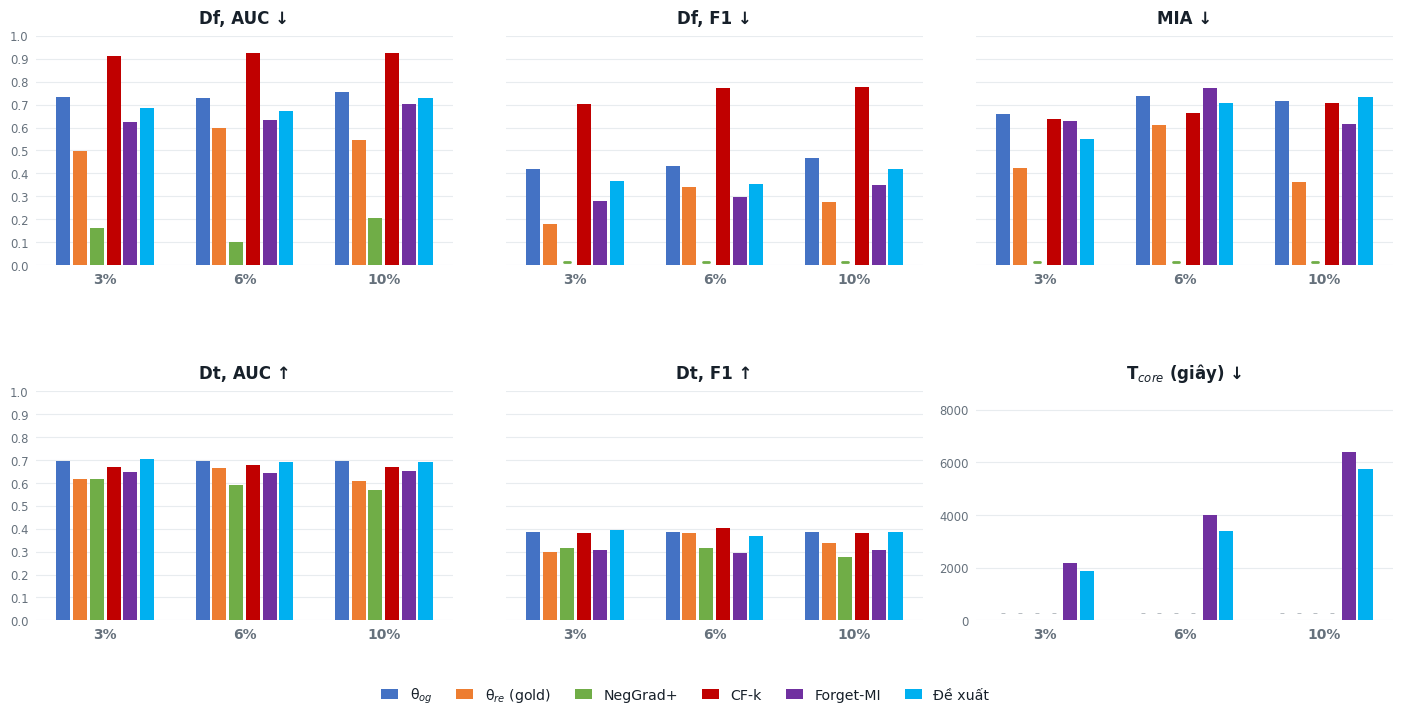

In [29]:
# =============================================================================
# CELL 4 — MIMIC: 5 chỉ số + thời gian lõi × 3 tỷ lệ quên
# =============================================================================
fig, _ = plot_6panels(
    data,
    ds="MIMIC",
    groups=FORGET_PCTS,
    suptitle="MIMIC-CXR — 5 chỉ số theo tỷ lệ quên",
    show_values=SHOW_VALUES_MIMIC,
    figsize=(14.6, 7.4),
)
save(fig, "fig_mimic_5metrics_clean")
plt.show()


saved: figures\fig_iu_5metrics_clean.png
saved: figures\fig_iu_5metrics_clean.pdf


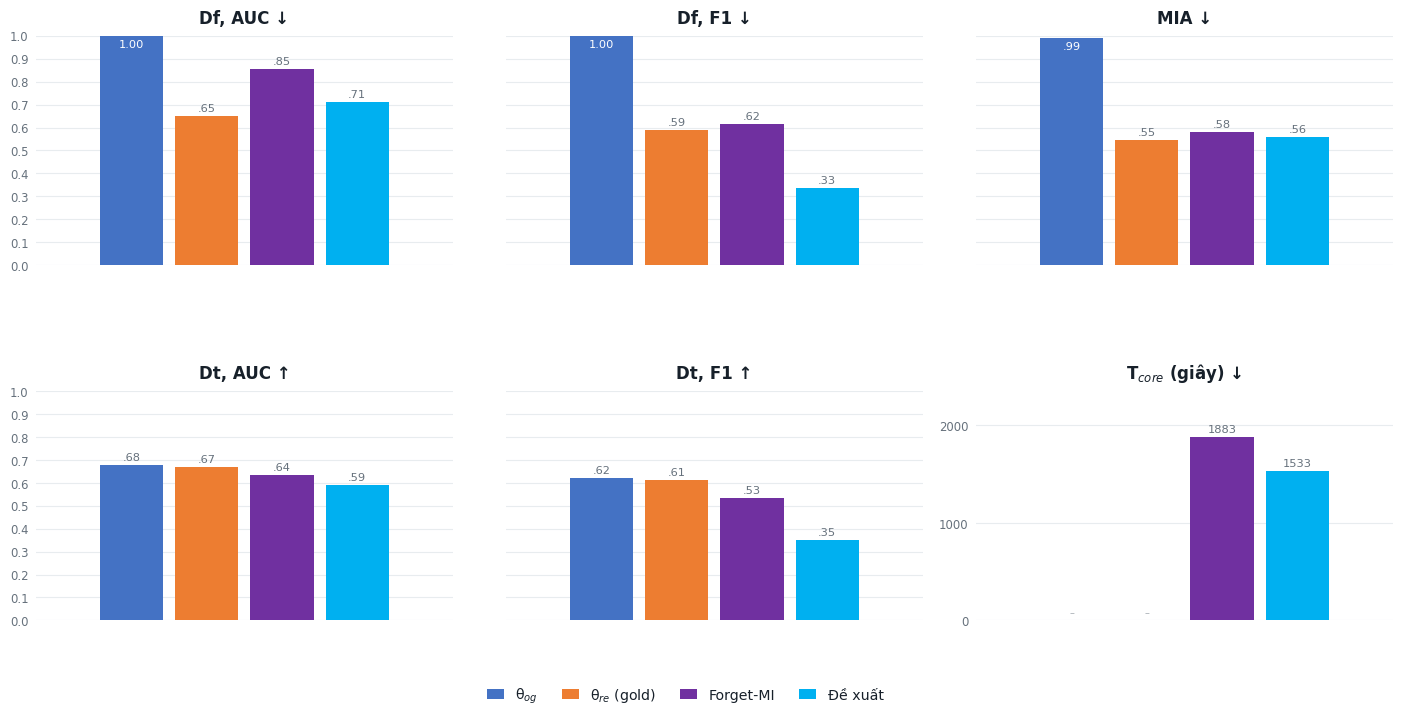

In [30]:
# =============================================================================
# CELL 5 — IU CXR: 5 chỉ số + thời gian lõi, tỷ lệ quên 3%
# =============================================================================
fig, axes = plot_6panels(
    data,
    ds="IU",
    groups=["3%"],
    suptitle="IU X-Ray — 5 chỉ số (tỷ lệ quên 3%)",
    show_values=SHOW_VALUES_IU,
    figsize=(14.6, 7.4),
    single_group=True,
    methods=METHODS_IU,      # bỏ NegGrad+ và CF-k: báo cáo không chạy trên IU
)
save(fig, "fig_iu_5metrics_clean")
plt.show()


saved: figures\fig_resource.png
saved: figures\fig_resource.pdf


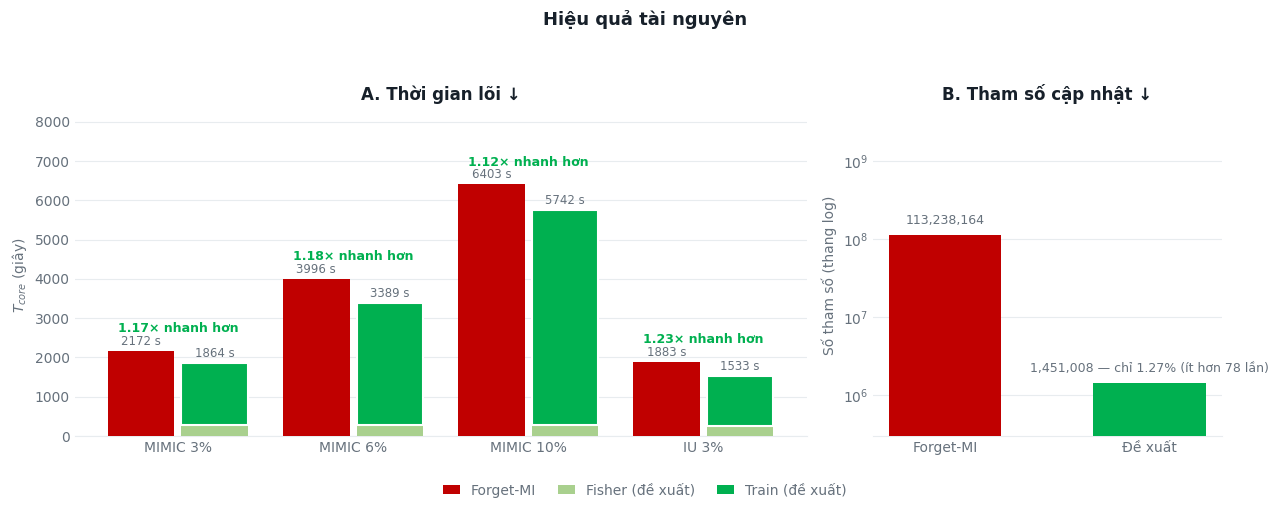

t_fisher_s  t_train_s  trainable_params
dataset forget_pct method                                            
MIMIC   3%         Forget-MI         0.0     2172.5       113238164.0
                   Ours            270.9     1592.7         1451008.0
        6%         Forget-MI         0.0     3995.5       113238164.0
                   Ours            286.9     3102.4         1451008.0
        10%        Forget-MI         0.0     6403.3       113238164.0
                   Ours            294.2     5447.5         1451008.0
IU      3%         Forget-MI         0.0     1882.6       113238164.0
                   Ours            259.3     1273.5         1451008.0

: 

In [ ]:
# =============================================================================
# CELL 6 — Chi phí tài nguyên (khớp fig:cost trong Chương 4)
#   Panel A: T_core = Fisher + Train (giây) — Forget-MI vs Đề xuất
#   Panel B: số tham số cập nhật (thang log)
# =============================================================================
COST_SETTINGS = [("MIMIC", "3%"), ("MIMIC", "6%"), ("MIMIC", "10%"), ("IU", "3%")]
C_FMI    = COST_COLORS["Forget-MI"]   # đỏ
C_OURS   = COST_COLORS["Ours"]        # xanh lá
C_FISHER = COST_COLORS["Fisher"]      # xanh lá nhạt

fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={"width_ratios": [2.1, 1]})

# ---- Panel A ---------------------------------------------------------------
labels, sp = [], 0.21
for i, (ds, pct) in enumerate(COST_SETTINGS):
    labels.append("%s %s" % (ds, pct))
    t_fmi = _get(data, ds, pct, "Forget-MI", "t_train_s") +             np.nan_to_num(_get(data, ds, pct, "Forget-MI", "t_fisher_s"))
    fish  = _get(data, ds, pct, "Ours", "t_fisher_s")
    train = _get(data, ds, pct, "Ours", "t_train_s")
    axA.bar(i - sp, t_fmi, width=0.38, color=C_FMI, linewidth=0, zorder=3)
    axA.bar(i + sp, fish,  width=0.38, color=C_FISHER, linewidth=0, zorder=3)
    axA.bar(i + sp, train, width=0.38, bottom=fish, color=C_OURS, zorder=3,
            edgecolor=C["surface"], linewidth=1.5)          # khe 2px giữa 2 phần
    tot = fish + train
    axA.text(i - sp, t_fmi + 80, "%d s" % round(t_fmi), ha="center", va="bottom",
             fontsize=8.5, color=C["secondary"], zorder=4)
    axA.text(i + sp, tot + 80, "%d s" % round(tot), ha="center", va="bottom",
             fontsize=8.5, color=C["secondary"], zorder=4)
    axA.text(i, max(t_fmi, tot) + 400, "%.2f× nhanh hơn" % (t_fmi / tot),
             ha="center", va="bottom", fontsize=9, fontweight="bold",
             color=C_OURS, zorder=4)

axA.set_xticks(range(len(labels))); axA.set_xticklabels(labels)
axA.set_ylabel("$T_{core}$ (giây)", fontsize=10)
axA.set_title("A. Thời gian lõi ↓", color=C["primary"], pad=10)
axA.set_ylim(0, 8200)
axA.yaxis.grid(True, color=C["grid"], linewidth=0.8, zorder=0); axA.set_axisbelow(True)
for k in ("top", "right", "left"): axA.spines[k].set_visible(False)
axA.spines["bottom"].set_color(C["grid"]); axA.tick_params(length=0)

# ---- Panel B ---------------------------------------------------------------
prm = [(_get(data, "MIMIC", "3%", m, "trainable_params"), m) for m in ("Forget-MI", "Ours")]
for i, (v, m) in enumerate(prm):
    axB.bar(i, v, width=0.55, color=COST_COLORS[m], linewidth=0, zorder=3)
    note = "" if m == "Forget-MI" else " — chỉ 1.27% (ít hơn 78 lần)"
    axB.text(i, v * 1.25, "{:,}".format(int(v)) + note, ha="center", va="bottom",
             fontsize=9, color=C["secondary"], zorder=4)
axB.set_yscale("log"); axB.set_ylim(3e5, 4e9)
axB.minorticks_off()
axB.set_xticks([0, 1]); axB.set_xticklabels(["Forget-MI", "Đề xuất"])
axB.set_ylabel("Số tham số (thang log)", fontsize=10)
axB.set_title("B. Tham số cập nhật ↓", color=C["primary"], pad=10)
axB.yaxis.grid(True, color=C["grid"], linewidth=0.8, zorder=0); axB.set_axisbelow(True)
for k in ("top", "right", "left"): axB.spines[k].set_visible(False)
axB.spines["bottom"].set_color(C["grid"]); axB.tick_params(length=0)

handles = [Patch(facecolor=C_FMI, label="Forget-MI"),
           Patch(facecolor=C_FISHER, label="Fisher (đề xuất)"),
           Patch(facecolor=C_OURS, label="Train (đề xuất)")]
fig.legend(handles=handles, loc="lower center", ncol=3, frameon=False,
           bbox_to_anchor=(0.5, -0.02), fontsize=10, labelcolor=C["secondary"],
           handlelength=1.2, columnspacing=1.6)
fig.suptitle("Hiệu quả tài nguyên", fontsize=13,
             fontweight="bold", color=C["primary"])
fig.tight_layout(rect=[0, 0.06, 1, 0.93])
save(fig, "fig_resource")
plt.show()

# FILA < 1 giây ở mọi thiết lập nên không vẽ theo tỷ lệ (giống chú thích fig:cost).
display(data[data.method.isin(["Forget-MI", "Ours"])]
        [["dataset", "forget_pct", "method"] + RES_COLS]
        .dropna(subset=["t_train_s"]).set_index(["dataset", "forget_pct", "method"]))